In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
root = "/content/drive/MyDrive/MangoSense"
checks = [
"datasets/preprocessed-leaves-dual/train",
"datasets/preprocessed-leaves-dual/val",
"datasets/preprocessed-leaves-dual/test",
"datasets/preprocessed-fruit-dual/train",
"datasets/preprocessed-fruit-dual/val",
"datasets/preprocessed-fruit-dual/test",
]
for c in checks:
    print(c, "->", os.path.isdir(os.path.join(root, c)))

datasets/preprocessed-leaves-dual/train -> True
datasets/preprocessed-leaves-dual/val -> True
datasets/preprocessed-leaves-dual/test -> True
datasets/preprocessed-fruit-dual/train -> True
datasets/preprocessed-fruit-dual/val -> True
datasets/preprocessed-fruit-dual/test -> True


In [ ]:
import os
import zipfile

# Define the path to your zip file in Google Drive
# Update this path if your zip file is located elsewhere
zip_path = '/content/drive/MyDrive/MangoSense/split-datasets-raw.zip'

# Define the directory where you want to extract the contents
extract_dir = '/content/drive/MyDrive/MangoSense/datasets'

print(f'Checking if zip file exists: {zip_path}')
if not os.path.exists(zip_path):
    print(f'Error: Zip file not found at {zip_path}')
else:
    print(f'Zip file found. Extracting to: {extract_dir}')
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print('Extraction complete!')


Checking if zip file exists: /content/drive/MyDrive/MangoSense/split-datasets-raw.zip
Zip file found. Extracting to: /content/drive/MyDrive/MangoSense/datasets
Extraction complete!


**Preprocessing**

In [ ]:
import os
import cv2
import numpy as np

# ============================================================
# COLAB SETUP
# ============================================================
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/MangoSense"
else:
    BASE_DIR = ""

def path_under_base(*parts):
    return os.path.join(BASE_DIR, *parts) if BASE_DIR else os.path.join(*parts)

# ============================================================
# CONFIG
# ============================================================
DATASETS = {
    "leaves": {
        "src_dir"     : path_under_base("datasets", "split-leaves-raw"),
        "img_out_dir" : path_under_base("datasets", "preprocessed-leaves-obj-crop"),
        "img_size"    : (240, 240),
    },
    "fruit": {
        "src_dir"     : path_under_base("datasets", "split-fruit-raw"),
        "img_out_dir" : path_under_base("datasets", "preprocessed-fruit-obj-crop"),
        "img_size"    : (240, 240),
    },
}

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# ============================================================
# Preprocessing pipeline
# ============================================================
def crop_to_subject(img_bgr, margin=0.08, padding=12, work_size=512):
    """
    GrabCut segmentation to isolate the foreground subject and crop
    to its bounding box. Falls back to the full image on failure or
    when the crop is degenerate (< 20% of working area).

    GrabCut runs on a downscaled copy (max work_size px) to keep
    memory usage flat for any source resolution. The bounding box is
    then mapped back to original coordinates before cropping.
    """
    original_height, original_width = img_bgr.shape[:2]

    # Downscale for GrabCut — keeps memory bounded regardless of source res
    scale = min(1.0, work_size / max(original_height, original_width))
    work_width, work_height = int(original_width * scale), int(original_height * scale)
    work = cv2.resize(img_bgr, (work_width, work_height), interpolation=cv2.INTER_AREA)

    rect      = (int(work_width * margin), int(work_height * margin),
                 int(work_width * (1 - 2 * margin)), int(work_height * (1 - 2 * margin)))
    mask      = np.zeros((work_height, work_width), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(work, mask, rect, bgd_model, fgd_model,
                    5, cv2.GC_INIT_WITH_RECT)
    except cv2.error:
        return img_bgr

    fg_mask = np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return img_bgr

    largest = max(contours, key=cv2.contourArea)
    contour_x, contour_y, contour_width, contour_height = cv2.boundingRect(largest)

    if contour_width * contour_height < 0.20 * work_width * work_height:
        return img_bgr

    # Map bounding box back to original resolution
    padding_orig_scale = max(1, int(padding / scale))
    crop_x1 = max(0, int(contour_x / scale) - padding_orig_scale)
    crop_y1 = max(0, int(contour_y / scale) - padding_orig_scale)
    crop_x2 = min(original_width, int((contour_x + contour_width) / scale) + padding_orig_scale)
    crop_y2 = min(original_height, int((contour_y + contour_height) / scale) + padding_orig_scale)

    cropped = img_bgr[crop_y1:crop_y2, crop_x1:crop_x2]
    return cropped if cropped.size > 0 else img_bgr


def preprocess(img_path, img_size):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_bgr = crop_to_subject(img_bgr)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img.astype("float32") / 255.0


# ============================================================
# Run for each dataset
# ============================================================
for dataset_name, dataset_config in DATASETS.items():
    src_dir     = dataset_config["src_dir"]
    img_out_dir = dataset_config["img_out_dir"]
    img_size    = dataset_config["img_size"]

    class_names = sorted([
        d for d in os.listdir(os.path.join(src_dir, "train"))
        if os.path.isdir(os.path.join(src_dir, "train", d))
    ])

    print(f"\n{'='*50}")
    print(f" Preprocessing: {dataset_name.upper()}")
    print(f"{'='*50}")
    print(f"Classes   : {class_names}")
    print(f"Image size: {img_size}\n")

    for split in ("train", "val", "test"):
        count = 0
        split_src = os.path.join(src_dir, split)

        for label, class_name in enumerate(class_names):
            cls_src     = os.path.join(split_src, class_name)
            cls_img_out = os.path.join(img_out_dir, split, class_name)
            os.makedirs(cls_img_out, exist_ok=True)

            skipped = 0
            for image_filename in os.listdir(cls_src):
                if os.path.splitext(image_filename)[1].lower() not in VALID_EXTS:
                    continue

                img = preprocess(os.path.join(cls_src, image_filename), img_size)
                if img is None:
                    skipped += 1
                    continue

                img_uint8 = (img * 255).astype(np.uint8)
                out_path  = os.path.join(cls_img_out, os.path.splitext(image_filename)[0] + ".png")
                cv2.imwrite(out_path, cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR))
                count += 1

            if skipped:
                print(f"  [{split}/{class_name}] skipped {skipped} unreadable file(s)")

        print(f"  {split:>5} → {count} images saved")

    print(f"Images saved to : {img_out_dir}")

print("\nAll datasets preprocessed.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Preprocessing: LEAVES
Classes   : ['Anthracnose', 'Die Back', 'Healthy', 'Powdery Mildew', 'Sooty Mold']
Image size: (240, 240)

  train — 1750 images saved
    val — 375 images saved
   test — 375 images saved
Images saved to : /content/drive/MyDrive/MangoSense/datasets/preprocessed-leaves-obj-crop

 Preprocessing: FRUIT
Classes   : ['Alternaria', 'Anthracnose', 'Black Mold Rot', 'Healthy', 'Stem end Rot']
Image size: (240, 240)

  train — 350 images saved
    val — 75 images saved
   test — 75 images saved
Images saved to : /content/drive/MyDrive/MangoSense/datasets/preprocessed-fruit-obj-crop

All datasets preprocessed.


Custom Cnn Symptom - Co Attention

In [ ]:
from google.colab import drive
import os, zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/MangoSense/symptom_data.zip'
extract_dir = '/content/drive/MyDrive/MangoSense'

print('Zip exists:', os.path.exists(zip_path))
if not os.path.exists(zip_path):
    raise FileNotFoundError(f'Not found: {zip_path}')

os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print('Extracted to:', extract_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip exists: True
Extracted to: /content/drive/MyDrive/MangoSense


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading symptom CSV: /content/drive/MyDrive/MangoSense/symptom_data/all_datasets_symptom_features.csv
Total rows: 3000
Datasets found: ['Leaves_Mixed', 'Mango_Fruits']

  Training MangoSenseNet-CoAttn — LEAVES
  LR: 0.001  |  Batch: 32  |  Epochs: 50  |  Modality dropout: 0.5
  Image dir: /content/drive/MyDrive/MangoSense/datasets/preprocessed-leaves-obj-crop
Found 1750 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
  Classes (5): ['Anthracnose', 'Die Back', 'Healthy', 'Powdery Mildew', 'Sooty Mold']
  Model parameters will be shown below ↓
  Symptom features: 43
  Class prototype norms:
    Anthracnose            norm=6.363
    Die Back               norm=7.135
    Healthy                norm=6.956
    Powdery Mildew         norm=4.951
    Sooty Mold             norm=7.121


Model: "MangoSenseNet_CoAttn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 240, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 240, 240,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 240, 240,  │        864 │ rescaling_2[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 120, 120,  │          0 │ activation_8[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 120, 120,  │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 60, 60,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 60, 60,    │     73,728 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 60, 60,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 30, 30,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 30, 30,    │    294,912 │ max_pooling2d_10… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │      1,024 │ conv2d_11[0][0] 

 Total params: 502,609 (1.92 MB)

 Trainable params: 501,563 (1.91 MB)

 Non-trainable params: 1,046 (4.09 KB)

  Total parameters: 502,609
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4277 - loss: 1.6787
Epoch 1: val_accuracy improved from None to 0.58933, saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-leaves-obj/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-leaves-obj/best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - accuracy: 0.5669 - loss: 1.2553 - val_accuracy: 0.5893 - val_loss: 0.7046 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7702 - loss: 0.7715
Epoch 2: val_accuracy improved from 0.58933 to 0.76800, saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-leaves-obj/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-leaves-obj/best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.7754 - loss: 0.7283 - val_accuracy: 0.7680 - val_loss: 0.79

  [B] Oracle symptoms (upper bound):       Acc=1.0000  Loss=0.0751
      Symptom benefit: +0.5% vs image-only

Classification Report (zero-symptom / image-only baseline):
                precision    recall  f1-score   support

   Anthracnose     1.0000    0.9733    0.9865        75
      Die Back     0.9868    1.0000    0.9934        75
       Healthy     0.9868    1.0000    0.9934        75
Powdery Mildew     1.0000    1.0000    1.0000        75
    Sooty Mold     1.0000    1.0000    1.0000        75

      accuracy                         0.9947       375
     macro avg     0.9947    0.9947    0.9946       375
  weighted avg     0.9947    0.9947    0.9946       375



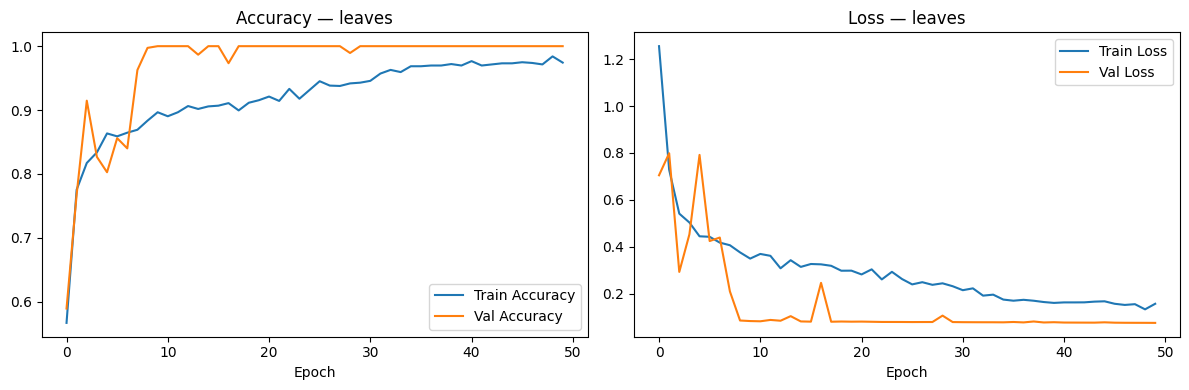

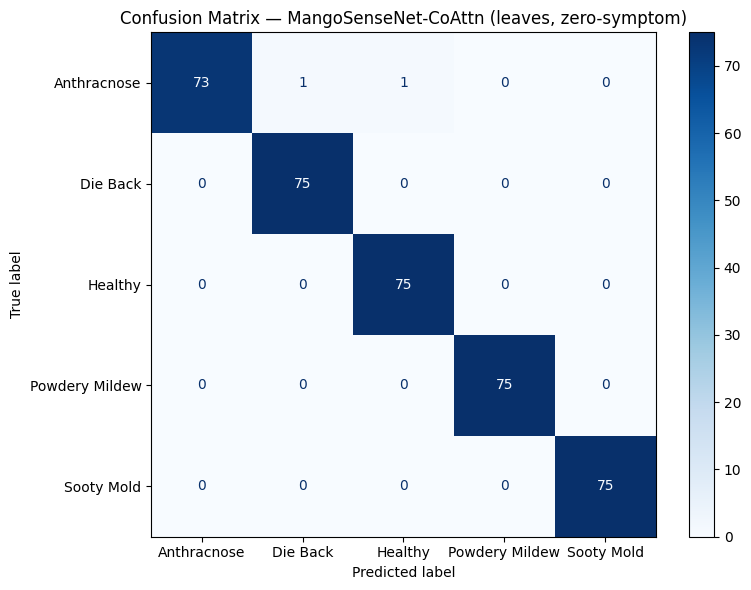

  Results saved to: /content/drive/MyDrive/MangoSense/models-custom-hybrid-leaves-obj

  Training MangoSenseNet-CoAttn — FRUIT
  LR: 0.001  |  Batch: 32  |  Epochs: 60  |  Modality dropout: 0.2
  Image dir: /content/drive/MyDrive/MangoSense/datasets/preprocessed-fruit-obj-crop
Found 350 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
  Classes (5): ['Alternaria', 'Anthracnose', 'Black Mold Rot', 'Healthy', 'Stem end Rot']
  Model parameters will be shown below ↓
  Symptom features: 43
  Class prototype norms:
    Alternaria             norm=3.883
    Anthracnose            norm=8.410
    Black Mold Rot         norm=4.799
    Healthy                norm=8.640
    Stem end Rot           norm=5.613


Model: "MangoSenseNet_CoAttn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 240, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 240, 240,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 240, 240,  │        864 │ rescaling_3[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 120, 120,  │          0 │ activation_12[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 120, 120,  │     18,432 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 60, 60,    │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 60, 60,    │     73,728 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 60, 60,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 30, 30,    │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 30, 30,    │    294,912 │ max_pooling2d_14… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │      1,024 │ conv2d_15[0][0] 

 Total params: 502,609 (1.92 MB)

 Trainable params: 501,563 (1.91 MB)

 Non-trainable params: 1,046 (4.09 KB)

  Total parameters: 502,609
Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.3007 - loss: 2.2531
Epoch 1: val_accuracy improved from None to 0.80000, saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-fruit-obj/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-fruit-obj/best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - accuracy: 0.4029 - loss: 1.7590 - val_accuracy: 0.8000 - val_loss: 0.4261 - learning_rate: 0.0010
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5438 - loss: 1.2392
Epoch 2: val_accuracy improved from 0.80000 to 1.00000, saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-fruit-obj/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-hybrid-fruit-obj/best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.5771 - loss: 1.1652 - val_accuracy: 1.0000 - val_loss: 0.2490 - 

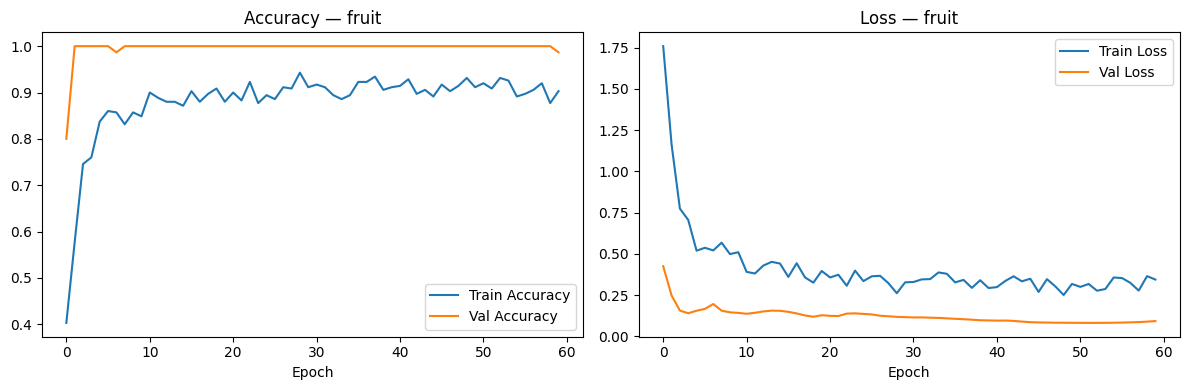

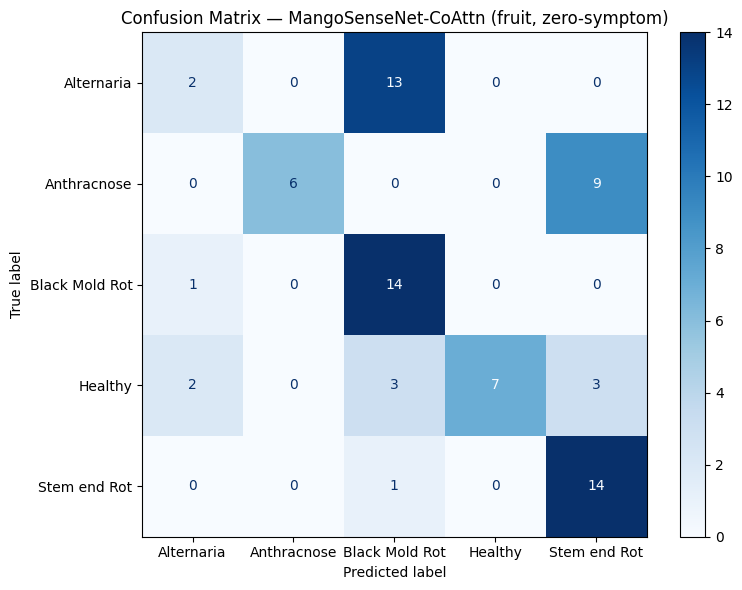

  Results saved to: /content/drive/MyDrive/MangoSense/models-custom-hybrid-fruit-obj

  FINAL RESULTS — MangoSenseNet-CoAttn
  Dataset    Image-only (A)     Oracle / +Symptoms (B)
  ----------------------------------------------------
  leaves     0.9947             1.0000  (+0.5%)
  fruit      0.5733             1.0000  (+42.7%)


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import json
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# ============================================================
# COLAB SETUP — update BASE_DIR if your folder name differs
# ============================================================
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/MangoSense"
else:
    BASE_DIR = ""

def path_under_base(*parts):
    """Join paths under BASE_DIR (works locally and on Colab)."""
    return os.path.join(BASE_DIR, *parts) if BASE_DIR else os.path.join(*parts)

# ============================================================
# CONFIG
# Images come from the preprocessed directories (already split).
# Symptom features are class-level averages from the CSV —
# no per-image filename matching is needed.
# ============================================================
SYMPTOM_CSV = path_under_base("symptom_data", "all_datasets_symptom_features.csv")

META_COLUMNS = {
    "dataset", "split", "class", "filename",
    "filepath", "relative_path", "color_dominant_hue_bin",
}

DATASETS = {
    "leaves": {
        "dataset_filter":  "Leaves_Mixed",
        "data_dir":        path_under_base("datasets", "preprocessed-leaves-obj-crop"),
        "save_dir":        path_under_base("models-custom-hybrid-leaves-obj"),
        "img_size":        (240, 240),
        "num_epochs":      50,
        "learning_rate":   1e-3,
        "batch_size":      32,
        "modality_dropout": 0.5,  # leaves are visually distinct — image branch can learn alone
    },
    "fruit": {
        "dataset_filter":  "Mango_Fruits",
        "data_dir":        path_under_base("datasets", "preprocessed-fruit-obj-crop"),
        "save_dir":        path_under_base("models-custom-hybrid-fruit-obj"),
        "img_size":        (240, 240),
        "num_epochs":      60,
        "learning_rate":   1e-3,
        "batch_size":      32,
        "modality_dropout": 0.2,  # fruit is visually subtle — allow symptoms to guide image learning
    },
}


# ============================================================
# Model definition — MangoSenseNet-CoAttn
# ============================================================
L2_REGULARIZER = tf.keras.regularizers.l2(1e-4)


def conv_block(image_features, filters):
    image_features = tf.keras.layers.Conv2D(
        filters, 3, padding="same", use_bias=False, kernel_regularizer=L2_REGULARIZER
    )(image_features)
    image_features = tf.keras.layers.BatchNormalization()(image_features)
    image_features = tf.keras.layers.Activation("relu")(image_features)
    image_features = tf.keras.layers.MaxPooling2D(2)(image_features)
    return image_features


def build_hybrid_model(input_shape, num_symptom_features, num_classes):
    TOKEN_DIM  = 16
    IMG_TOKENS = 16   # 16 × 16 = 256-dim total, matches Dense(256)
    SYM_TOKENS = 4    # 4  × 16 = 64-dim total,  matches Dense(64)
    NUM_HEADS  = 4
    KEY_DIM    = TOKEN_DIM // NUM_HEADS   # = 4

    # --- Image branch ---
    img_input = tf.keras.Input(shape=input_shape, name="image")

    augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ], name="augmentation")

    image_features = augmentation(img_input)
    image_features = tf.keras.layers.Rescaling(1.0 / 255.0)(image_features)
    image_features = conv_block(image_features, 32)   # → 120×120×32
    image_features = conv_block(image_features, 64)   # → 60×60×64
    image_features = conv_block(image_features, 128)  # → 30×30×128
    image_features = conv_block(image_features, 256)  # → 15×15×256
    image_features = tf.keras.layers.GlobalAveragePooling2D(name="image_gap")(image_features)
    image_features = tf.keras.layers.Dense(
        IMG_TOKENS * TOKEN_DIM, activation="relu", kernel_regularizer=L2_REGULARIZER
    )(image_features)
    image_features = tf.keras.layers.Dropout(0.5, name="img_dropout")(image_features)
    img_tokens = tf.keras.layers.Reshape(
        (IMG_TOKENS, TOKEN_DIM), name="img_tokens"
    )(image_features)  # (B, 16, 16)

    # --- Symptom branch ---
    sym_input = tf.keras.Input(shape=(num_symptom_features,), name="symptoms")
    symptom_features = tf.keras.layers.BatchNormalization()(sym_input)
    symptom_features = tf.keras.layers.Dense(
        SYM_TOKENS * TOKEN_DIM, activation="relu", kernel_regularizer=L2_REGULARIZER
    )(symptom_features)
    symptom_features = tf.keras.layers.Dropout(0.3, name="sym_dropout")(symptom_features)
    sym_tokens = tf.keras.layers.Reshape(
        (SYM_TOKENS, TOKEN_DIM), name="sym_tokens"
    )(symptom_features)  # (B, 4, 16)

    # --- Bi-directional co-attention ---
    # Image tokens query symptom tokens: "which symptoms explain what I see?"
    img_attended = tf.keras.layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=KEY_DIM, name="img_attends_sym"
    )(query=img_tokens, key=sym_tokens, value=sym_tokens)  # (B, 16, 16)

    # Symptom tokens query image tokens: "which visual features match these symptoms?"
    sym_attended = tf.keras.layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=KEY_DIM, name="sym_attends_img"
    )(query=sym_tokens, key=img_tokens, value=img_tokens)  # (B, 4, 16)

    # Residual + LayerNorm (standard transformer sub-layer pattern)
    img_out = tf.keras.layers.LayerNormalization(name="img_layernorm")(
        img_tokens + img_attended)  # (B, 16, 16)
    sym_out = tf.keras.layers.LayerNormalization(name="sym_layernorm")(
        sym_tokens + sym_attended)  # (B, 4, 16)

    # --- Fusion head ---
    img_flat = tf.keras.layers.Dropout(0.3)(
        tf.keras.layers.Flatten(name="img_flat")(img_out))  # (B, 256)
    sym_flat = tf.keras.layers.Dropout(0.3)(
        tf.keras.layers.Flatten(name="sym_flat")(sym_out))  # (B, 64)
    fused = tf.keras.layers.Concatenate(name="fusion")([img_flat, sym_flat])  # (B, 320)
    out = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=L2_REGULARIZER)(fused)
    out = tf.keras.layers.Dropout(0.4)(out)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(out)

    return tf.keras.Model(
        inputs={"image": img_input, "symptoms": sym_input},
        outputs=outputs,
        name="MangoSenseNet_CoAttn",
    )


# ============================================================
# Symptom feature helpers
# ============================================================
def compute_class_means(symptom_df, feature_cols, class_names):
    """Return (num_classes, num_features) array of per-class mean features."""
    means = symptom_df.groupby("class")[feature_cols].mean()
    return np.array([
        means.loc[class_name].values if class_name in means.index else np.zeros(len(feature_cols))
        for class_name in class_names
    ], dtype=np.float32)


def attach_class_symptoms(class_feat_tensor, training=False, dropout_rate=0.5):
    """
    Returns a tf.data map fn that attaches class-prototype symptom features.

    During training (training=True), randomly zeros the entire symptom vector
    for each sample with probability `dropout_rate` (modality dropout).
    This prevents the image branch from relying on the prototype as a shortcut
    to the correct class label, forcing it to learn visual features independently.

    During evaluation (training=False), always attaches the class prototype
    (oracle mode — upper bound to show hybrid model potential).
    """
    def attach_fn(image, label):
        class_idx = tf.argmax(label, axis=-1)
        symptoms  = tf.gather(class_feat_tensor, class_idx)
        if training:
            batch_size = tf.shape(symptoms)[0]
            keep_mask = tf.cast(
                tf.random.uniform([batch_size, 1]) > dropout_rate,
                tf.float32,
            )
            symptoms = symptoms * keep_mask
        return {"image": image, "symptoms": symptoms}, label
    return attach_fn


def zero_symptoms_fn(num_features):
    """Returns a tf.data map fn that zeros all symptom features (honest baseline)."""
    def zero_fn(image, label):
        zeros = tf.zeros((tf.shape(image)[0], num_features), dtype=tf.float32)
        return {"image": image, "symptoms": zeros}, label
    return zero_fn


# ============================================================
# Train each dataset
# ============================================================
all_results = {}

print(f"Loading symptom CSV: {SYMPTOM_CSV}")
symptom_df_all = pd.read_csv(SYMPTOM_CSV)
print(f"Total rows: {len(symptom_df_all)}")
print(f"Datasets found: {symptom_df_all['dataset'].unique().tolist()}")

for dataset_name, dataset_config in DATASETS.items():
    dataset_filter   = dataset_config["dataset_filter"]
    data_dir         = dataset_config["data_dir"]
    save_dir         = dataset_config["save_dir"]
    img_size         = dataset_config["img_size"]
    num_epochs       = dataset_config["num_epochs"]
    learning_rate    = dataset_config["learning_rate"]
    batch_size       = dataset_config["batch_size"]
    modality_dropout = dataset_config["modality_dropout"]
    input_shape      = (*img_size, 3)

    print(f"\n{'='*55}")
    print(f"  Training MangoSenseNet-CoAttn — {dataset_name.upper()}")
    print(f"{'='*55}")
    print(f"  LR: {learning_rate}  |  Batch: {batch_size}  |  Epochs: {num_epochs}  |  Modality dropout: {modality_dropout}")
    print(f"  Image dir: {data_dir}")

    if not os.path.isdir(data_dir):
        print(f"  ERROR: Image directory not found: {data_dir}")
        continue

    AUTOTUNE = tf.data.AUTOTUNE

    # Load preprocessed images (already split into train/val/test)
    train_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "train"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=True, seed=42,
    )
    val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "val"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=False,
    )
    test_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "test"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=False,
    )

    class_names  = train_ds_raw.class_names
    num_classes  = len(class_names)
    print(f"  Classes ({num_classes}): {class_names}")
    print(f"  Model parameters will be shown below ↓")

    # Compute class-mean symptom features from CSV
    symptom_df = symptom_df_all[symptom_df_all["dataset"] == dataset_filter].copy()
    if symptom_df.empty:
        print(f"  WARNING: No CSV rows for '{dataset_filter}'. Skipping.")
        continue

    feature_cols = [
        col for col in symptom_df.columns
        if col not in META_COLUMNS and pd.api.types.is_numeric_dtype(symptom_df[col])
    ]
    symptom_df = symptom_df.dropna(subset=feature_cols)
    print(f"  Symptom features: {len(feature_cols)}")

    class_means_raw    = compute_class_means(symptom_df, feature_cols, class_names)
    scaler             = StandardScaler()
    class_means_scaled = scaler.fit_transform(class_means_raw).astype(np.float32)
    class_feat_tensor  = tf.constant(class_means_scaled)

    print("  Class prototype norms:")
    for class_index, class_name in enumerate(class_names):
        print(f"    {class_name:<22} norm={np.linalg.norm(class_means_scaled[class_index]):.3f}")

    num_features  = len(feature_cols)
    train_attach  = attach_class_symptoms(class_feat_tensor, training=True,  dropout_rate=modality_dropout)
    oracle_attach = attach_class_symptoms(class_feat_tensor, training=False)
    zero_attach   = zero_symptoms_fn(num_features)

    # Training: modality dropout forces image branch to learn visual features alone
    # Val:      oracle prototype (so val_accuracy measures hybrid performance)
    # Test:     evaluated twice — zero (honest baseline) and oracle (upper bound)
    train_ds = (
        train_ds_raw.cache().shuffle(1000, seed=42)
        .map(train_attach,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )
    val_ds = (
        val_ds_raw.cache()
        .map(oracle_attach, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )

    # Build and compile model
    model = build_hybrid_model(input_shape, num_features, num_classes)
    model.summary()
    print(f"  Total parameters: {model.count_params():,}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    os.makedirs(save_dir, exist_ok=True)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(save_dir, "best_model.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
    ]

    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=num_epochs, callbacks=callbacks, verbose=1,
    )

    # ── Evaluation ────────────────────────────────────────────────────────────────────────
    # (A) Zero-symptom — image branch only (honest baseline for thesis)
    test_zero = (
        test_ds_raw.cache()
        .map(zero_attach,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )
    loss_zero, acc_zero = model.evaluate(test_zero, verbose=0)
    print(f"\n  [A] Zero-symptom (image-only baseline):  Acc={acc_zero:.4f}  Loss={loss_zero:.4f}")

    y_pred_zero = np.argmax(model.predict(test_zero, verbose=0), axis=1)
    y_true      = np.argmax(np.concatenate([y.numpy() for _, y in test_zero]), axis=1)

    # (B) Oracle — true class prototype (theoretical upper bound)
    test_oracle = (
        test_ds_raw.cache()
        .map(oracle_attach, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )
    loss_oracle, acc_oracle = model.evaluate(test_oracle, verbose=0)
    print(f"  [B] Oracle symptoms (upper bound):       Acc={acc_oracle:.4f}  Loss={loss_oracle:.4f}")
    print(f"      Symptom benefit: +{(acc_oracle - acc_zero)*100:.1f}% vs image-only")

    report = classification_report(y_true, y_pred_zero, target_names=class_names, digits=4)
    print("\nClassification Report (zero-symptom / image-only baseline):")
    print(report)

    # ── Save artifacts ──────────────────────────────────────────────────────────────────────────
    model.save(os.path.join(save_dir, "hybrid_cnn.keras"))
    joblib.dump(scaler, os.path.join(save_dir, "symptom_scaler.joblib"))

    with open(os.path.join(save_dir, "feature_columns.json"), "w") as output_file:
        json.dump(feature_cols, output_file)

    class_proto = {class_name: class_means_scaled[class_index].tolist() for class_index, class_name in enumerate(class_names)}
    with open(os.path.join(save_dir, "class_symptom_prototypes.json"), "w") as output_file:
        json.dump(class_proto, output_file)

    with open(os.path.join(save_dir, "history.json"), "w") as output_file:
        json.dump(history.history, output_file)

    with open(os.path.join(save_dir, "classification_report.txt"), "w") as output_file:
        output_file.write(f"Dataset: {dataset_name}\n")
        output_file.write(f"Accuracy (zero-symptom / image-only): {acc_zero:.4f}\n")
        output_file.write(f"Accuracy (oracle / upper bound):      {acc_oracle:.4f}\n")
        output_file.write(f"Loss     (zero-symptom):              {loss_zero:.4f}\n\n")
        output_file.write(report)

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title(f"Accuracy — {dataset_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(f"Loss — {dataset_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
    plt.show()

    # Confusion matrix (zero-symptom results)
    cm   = confusion_matrix(y_true, y_pred_zero)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap="Blues", ax=ax)
    plt.title(f"Confusion Matrix — MangoSenseNet-CoAttn ({dataset_name}, zero-symptom)")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
    plt.show()

    all_results[dataset_name] = {
        "acc_zero":   round(acc_zero,   4),
        "acc_oracle": round(acc_oracle, 4),
        "loss_zero":  round(loss_zero,  4),
    }
    print(f"  Results saved to: {save_dir}")

# ============================================================
# Final summary
# ============================================================
print(f"\n{'='*55}")
print("  FINAL RESULTS — MangoSenseNet-CoAttn")
print(f"{'='*55}")
print(f"  {'Dataset':<10} {'Image-only (A)':<18} {'Oracle / +Symptoms (B)'}")
print(f"  {'-'*52}")
for dataset_name, result_summary in all_results.items():
    oracle_gain_pct = (result_summary['acc_oracle'] - result_summary['acc_zero']) * 100
    print(f"  {dataset_name:<10} {result_summary['acc_zero']:.4f}             {result_summary['acc_oracle']:.4f}  (+{oracle_gain_pct:.1f}%)")


CUSTOM CNN BASE MODEL

Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-44e3eb4d-57f4-4e1a-951e-7f172cff9e1e.json']
Auto-detected Colab base directory: /content/drive/MyDrive/MangoSense
Running in Colab: True
Base directory: /content/drive/MyDrive/MangoSense

  Training MangoSenseNet-Base — LEAVES
  LR: 0.001  |  Batch: 32  |  Epochs: 50
Found 1750 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
  Classes (5): ['Anthracnose', 'Die Back', 'Healthy', 'Powdery Mildew', 'Sooty Mold']


Model: "MangoSenseNet_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 240, 240, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 120, 120, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 60, 60, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 30, 30, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 456,933 (1.74 MB)

 Trainable params: 455,973 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

  Total parameters: 456,933
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5676 - loss: 1.1424
Epoch 1: val_accuracy improved from None to 0.20000, saving model to /content/drive/MyDrive/MangoSense/models-custom-cnn-leaves/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-cnn-leaves/best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.6989 - loss: 0.8679 - val_accuracy: 0.2000 - val_loss: 1.7961 - learning_rate: 0.0010
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8295 - loss: 0.5683
Epoch 2: val_accuracy did not improve from 0.20000
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.8331 - loss: 0.5311 - val_accuracy: 0.1760 - val_loss: 2.3141 - learning_rate: 0.0010
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8628 - loss: 0.4295
Epoch 3: val_accuracy did not improve from 0.20000
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.8840 - loss: 0.396

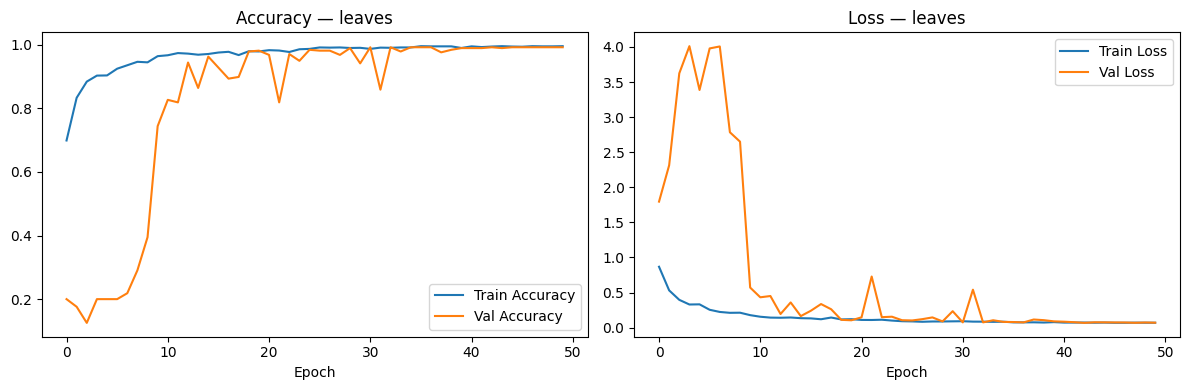

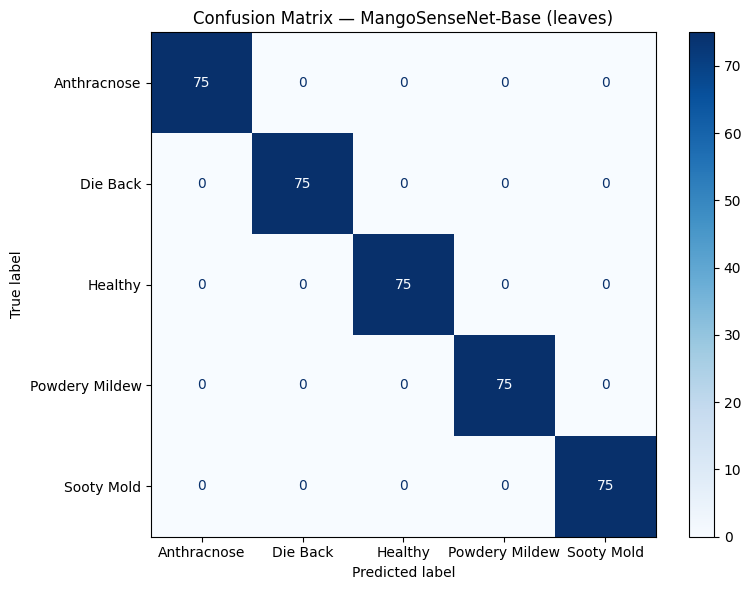

  Results saved to: /content/drive/MyDrive/MangoSense/models-custom-cnn-leaves

  Training MangoSenseNet-Base — FRUIT
  LR: 0.001  |  Batch: 32  |  Epochs: 50
Found 350 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
  Classes (5): ['Alternaria', 'Anthracnose', 'Black Mold Rot', 'Healthy', 'Stem end Rot']


Model: "MangoSenseNet_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 240, 240, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 120, 120, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 60, 60, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 30, 30, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 456,933 (1.74 MB)

 Trainable params: 455,973 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

  Total parameters: 456,933
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4188 - loss: 1.4624
Epoch 1: val_accuracy improved from None to 0.22667, saving model to /content/drive/MyDrive/MangoSense/models-custom-cnn-fruit/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-custom-cnn-fruit/best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.5057 - loss: 1.2954 - val_accuracy: 0.2267 - val_loss: 1.6472 - learning_rate: 0.0010
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5761 - loss: 1.0612
Epoch 2: val_accuracy did not improve from 0.22667
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.6086 - loss: 0.9759 - val_accuracy: 0.2133 - val_loss: 1.6741 - learning_rate: 0.0010
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6898 - loss: 0.8492
Epoch 3: val_accuracy did not improve from 0.22667
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.6971 - loss: 0.8635 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
                precision    recall  f1-score   support

    Alternaria     0.3913    0.6000    0.4737        15
   Anthracnose     0.0000    0.0000    0.0000        15
Black Mold Rot     0.0000    0.0000    0.0000        15
       Healthy     0.2955    0.8667    0.4407        15
  Stem end Rot     0.0000    0.0000    0.0000        15

      accuracy                         0.2933        75
     macro avg     0.1374    0.2933    0.1829        75
  weighted avg     0.1374    0.2933    0.1829        75



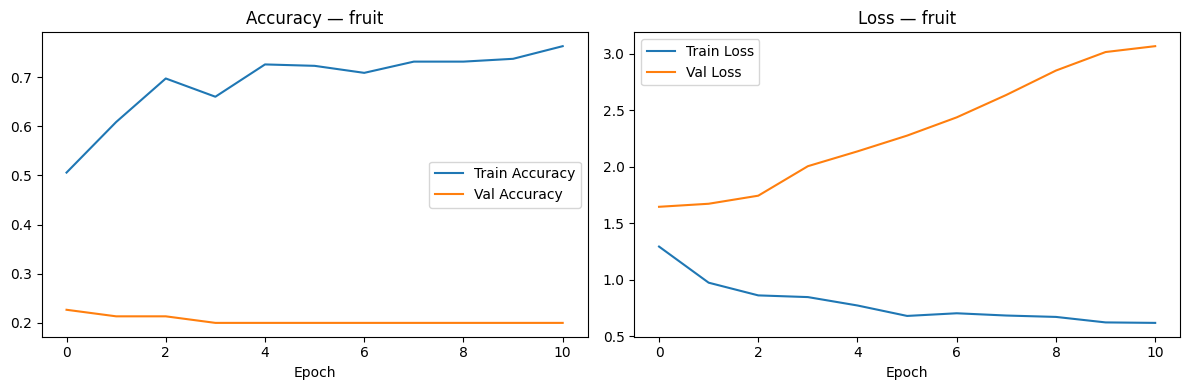

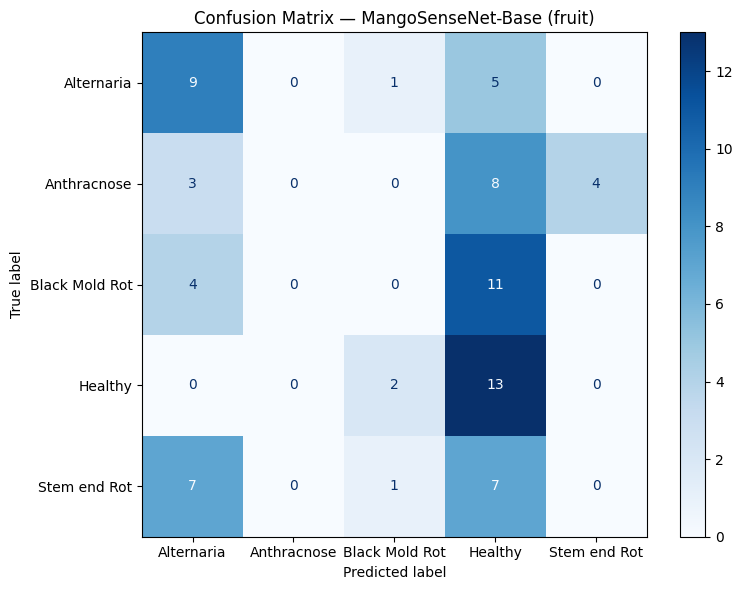

  Results saved to: /content/drive/MyDrive/MangoSense/models-custom-cnn-fruit

  FINAL RESULTS — MangoSenseNet-Base
  leaves   Accuracy: 1.0000  Loss: 0.0555
  fruit    Accuracy: 0.2933  Loss: 1.6575


In [ ]:
import tensorflow as tf
import numpy as np
import os
import json
import argparse
import sys
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
DATASETS = {
    "leaves": {
        "data_dir":      "datasets/preprocessed-leaves-dual",
        "save_dir":      "models-custom-cnn-leaves",
        "img_size":      (240, 240),
        "num_epochs":    50,
        "learning_rate": 1e-3,
        "batch_size":    32,
    },
    "fruit": {
        "data_dir":      "datasets/preprocessed-fruit-dual",
        "save_dir":      "models-custom-cnn-fruit",
        "img_size":      (240, 240),
        "num_epochs":    50,
        "learning_rate": 1e-3,
        "batch_size":    32,
    },
}

COLAB_BASE_DIR_CANDIDATES = [
    "/content/drive/MyDrive/MangoSense",
    "/content/drive/MyDrive/MangoSenseFinalDefense",
    "/content/MangoSenseFinalDefense",
]


def running_in_colab():
    return "google.colab" in sys.modules


def parse_args():
    parser = argparse.ArgumentParser(
        description="Train MangoSenseNet-Base on leaves and fruit datasets."
    )
    parser.add_argument(
        "--base-dir",
        default=".",
        help="Project root path. Dataset and model paths are resolved relative to this directory.",
    )
    parser.add_argument(
        "--mount-drive",
        action="store_true",
        help="Mount Google Drive first (only used in Colab).",
    )
    parser.add_argument(
        "--drive-mount-point",
        default="/content/drive",
        help="Drive mount point used in Colab.",
    )
    parser.add_argument(
        "--epochs",
        type=int,
        default=None,
        help="Optional epoch override for both datasets.",
    )

    # Jupyter/Colab injects arguments like "-f <kernel.json>".
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"Ignoring unknown arguments: {unknown}")
    return args


def maybe_mount_google_drive(args):
    if not args.mount_drive:
        return
    if not running_in_colab():
        print("WARNING: --mount-drive was set, but this runtime is not Colab. Skipping mount.")
        return

    from google.colab import drive  # type: ignore

    drive.mount(args.drive_mount_point)


def resolve_path(base_dir, relative_path):
    if os.path.isabs(relative_path):
        return relative_path
    return os.path.normpath(os.path.join(base_dir, relative_path))


def resolve_base_dir(args):
    # If user explicitly provided a value, respect it.
    if args.base_dir != ".":
        return os.path.abspath(args.base_dir)

    # In Colab, prefer known project locations when available.
    if running_in_colab():
        for candidate in COLAB_BASE_DIR_CANDIDATES:
            if os.path.isdir(candidate):
                print(f"Auto-detected Colab base directory: {candidate}")
                return candidate

    return os.path.abspath(args.base_dir)


# ============================================================
# Model definition — MangoSenseNet-Base
# ============================================================
L2_REGULARIZER = tf.keras.regularizers.l2(1e-4)


def conv_block(image_features, filters):
    image_features = tf.keras.layers.Conv2D(
        filters, 3, padding="same", use_bias=False, kernel_regularizer=L2_REGULARIZER
    )(image_features)
    image_features = tf.keras.layers.BatchNormalization()(image_features)
    image_features = tf.keras.layers.Activation("relu")(image_features)
    image_features = tf.keras.layers.MaxPooling2D(2)(image_features)
    return image_features


def build_custom_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape, name="image")

    augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ], name="augmentation")

    image_features = augmentation(inputs)
    image_features = tf.keras.layers.Rescaling(1.0 / 255.0)(image_features)

    image_features = conv_block(image_features, 32)   # → 120×120×32
    image_features = conv_block(image_features, 64)   # → 60×60×64
    image_features = conv_block(image_features, 128)  # → 30×30×128
    image_features = conv_block(image_features, 256)  # → 15×15×256

    image_features = tf.keras.layers.GlobalAveragePooling2D()(image_features)
    image_features = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=L2_REGULARIZER)(image_features)
    image_features = tf.keras.layers.Dropout(0.5)(image_features)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(image_features)

    return tf.keras.Model(inputs, outputs, name="MangoSenseNet_Base")


def main():
    args = parse_args()
    maybe_mount_google_drive(args)
    base_dir = resolve_base_dir(args)

    print(f"Running in Colab: {running_in_colab()}")
    print(f"Base directory: {base_dir}")

    # ============================================================
    # Train each dataset
    # ============================================================
    all_results = {}

    for dataset_name, dataset_config in DATASETS.items():
        data_dir      = resolve_path(base_dir, dataset_config["data_dir"])
        save_dir      = resolve_path(base_dir, dataset_config["save_dir"])
        img_size      = dataset_config["img_size"]
        num_epochs    = args.epochs if args.epochs is not None else dataset_config["num_epochs"]
        learning_rate = dataset_config["learning_rate"]
        batch_size    = dataset_config["batch_size"]
        input_shape   = (*img_size, 3)

        required_dirs = [
            os.path.join(data_dir, "train"),
            os.path.join(data_dir, "val"),
            os.path.join(data_dir, "test"),
        ]
        missing_dirs = [path for path in required_dirs if not os.path.isdir(path)]
        if missing_dirs:
            print(f"\nERROR: Missing dataset directories for '{dataset_name}'.")
            for missing in missing_dirs:
                print(f"  - {missing}")
            print("Skipping this dataset.")
            continue

        print(f"\n{'='*55}")
        print(f"  Training MangoSenseNet-Base — {dataset_name.upper()}")
        print(f"{'='*55}")
        print(f"  LR: {learning_rate}  |  Batch: {batch_size}  |  Epochs: {num_epochs}")

        AUTOTUNE = tf.data.AUTOTUNE

        train_ds = tf.keras.utils.image_dataset_from_directory(
            os.path.join(data_dir, "train"),
            image_size=img_size, batch_size=batch_size,
            label_mode="categorical", shuffle=True, seed=42,
        )
        val_ds = tf.keras.utils.image_dataset_from_directory(
            os.path.join(data_dir, "val"),
            image_size=img_size, batch_size=batch_size,
            label_mode="categorical", shuffle=False, seed=42,
        )
        test_ds = tf.keras.utils.image_dataset_from_directory(
            os.path.join(data_dir, "test"),
            image_size=img_size, batch_size=batch_size,
            label_mode="categorical", shuffle=False, seed=42,
        )

        class_names = train_ds.class_names
        num_classes = len(class_names)
        print(f"  Classes ({num_classes}): {class_names}")

        train_ds = train_ds.cache().shuffle(1000, seed=42).prefetch(AUTOTUNE)
        val_ds   = val_ds.cache().prefetch(AUTOTUNE)
        test_ds  = test_ds.cache().prefetch(AUTOTUNE)

        model = build_custom_cnn(input_shape, num_classes)
        model.summary()
        print(f"  Total parameters: {model.count_params():,}")

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )

        os.makedirs(save_dir, exist_ok=True)
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True, verbose=1,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=4, verbose=1,
            ),
            tf.keras.callbacks.ModelCheckpoint(
                os.path.join(save_dir, "best_model.keras"),
                monitor="val_accuracy", save_best_only=True, verbose=1,
            ),
        ]

        history = model.fit(
            train_ds, validation_data=val_ds,
            epochs=num_epochs, callbacks=callbacks, verbose=1,
        )

        test_loss, test_acc = model.evaluate(test_ds, verbose=0)
        print(f"\n  Test Accuracy : {test_acc:.4f}")
        print(f"  Test Loss     : {test_loss:.4f}")

        y_true        = np.concatenate([y.numpy() for _, y in test_ds])
        y_true_labels = np.argmax(y_true, axis=1)
        y_pred_probs  = model.predict(test_ds, verbose=0)
        y_pred_labels = np.argmax(y_pred_probs, axis=1)

        report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, digits=4)
        print("\nClassification Report:")
        print(report)

        model.save(os.path.join(save_dir, "custom_cnn.keras"))

        with open(os.path.join(save_dir, "history.json"), "w") as output_file:
            json.dump(history.history, output_file)

        with open(os.path.join(save_dir, "classification_report.txt"), "w") as output_file:
            output_file.write(f"Dataset: {dataset_name}\n")
            output_file.write(f"Test Accuracy: {test_acc:.4f}\n")
            output_file.write(f"Test Loss: {test_loss:.4f}\n\n")
            output_file.write(report)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history.history["accuracy"], label="Train Accuracy")
        axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
        axes[0].set_title(f"Accuracy — {dataset_name}")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        axes[1].plot(history.history["loss"], label="Train Loss")
        axes[1].plot(history.history["val_loss"], label="Val Loss")
        axes[1].set_title(f"Loss — {dataset_name}")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
        plt.show()

        cm   = confusion_matrix(y_true_labels, y_pred_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap="Blues", ax=ax)
        plt.title(f"Confusion Matrix — MangoSenseNet-Base ({dataset_name})")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
        plt.show()

        all_results[dataset_name] = {"test_accuracy": round(test_acc, 4), "test_loss": round(test_loss, 4)}
        print(f"  Results saved to: {save_dir}")

    # ============================================================
    # Final summary
    # ============================================================
    print(f"\n{'='*40}")
    print("  FINAL RESULTS — MangoSenseNet-Base")
    print(f"{'='*40}")
    for dataset_name, result_summary in all_results.items():
        print(f"  {dataset_name:<8} Accuracy: {result_summary['test_accuracy']:.4f}  Loss: {result_summary['test_loss']:.4f}")

    if not all_results:
        print("No training runs were completed. Verify --base-dir and dataset folder structure.")


if __name__ == "__main__":
    main()


MOBILENETV2 MODEL


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  Training MobileNetV2 — LEAVES
  Phase 1: 10 epochs frozen  (LR=0.001)
  Phase 2: 40 epochs fine-tune (LR=1e-05, top 30 layers)
  Image dir: /content/drive/MyDrive/MangoSense/datasets/preprocessed-leaves
Found 1750 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
Found 375 files belonging to 5 classes.
  Classes (5): ['Anthracnose', 'Die Back', 'Healthy', 'Powdery Mildew', 'Sooty Mold']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_MangoSense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Rescaling)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

  Total parameters (phase 1): 2,587,205

  ── Phase 1: Training classification head (base frozen) ──
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7065 - loss: 0.7608
Epoch 1: val_accuracy improved from None to 0.91200, saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-leaves-2/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-leaves-2/best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 1099s 4s/step - accuracy: 0.8411 - loss: 0.4256 - val_accuracy: 0.9120 - val_loss: 0.1984
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9373 - loss: 0.1687
Epoch 2: val_accuracy improved from 0.91200 to 0.96800, saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-leaves-2/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-leaves-2/best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9463 - loss: 0.1524 - val_accur

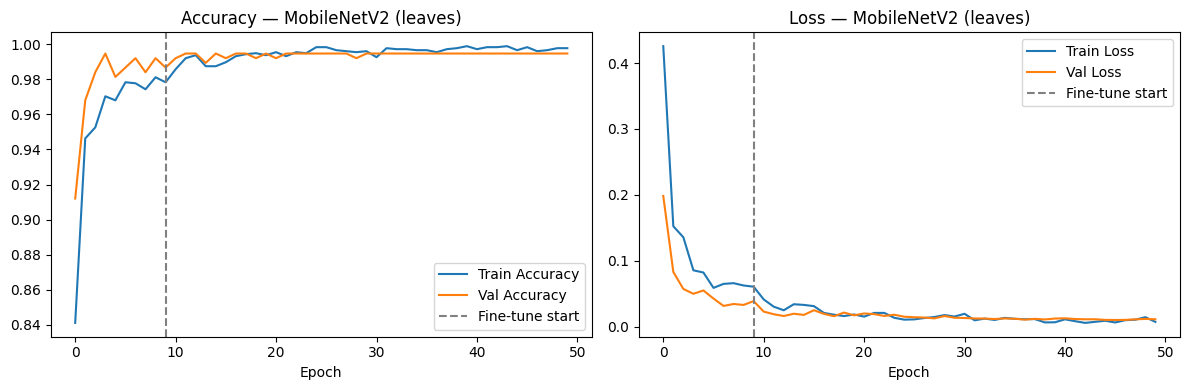

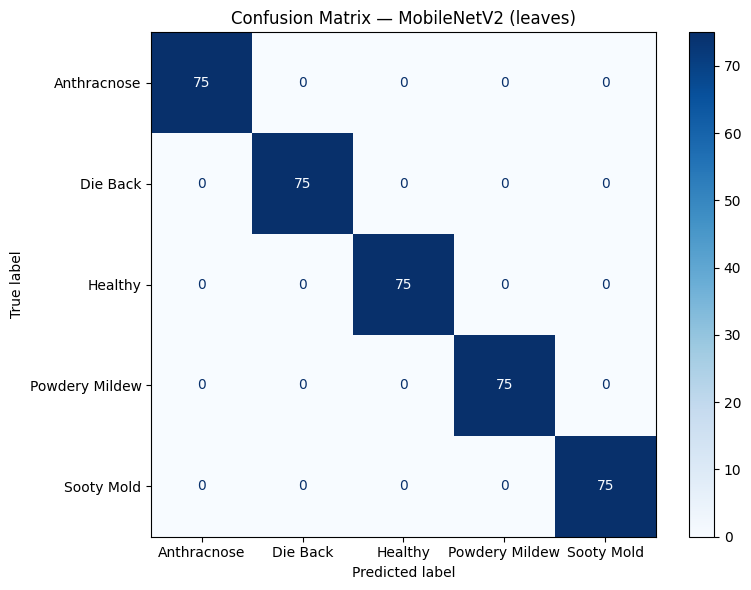

  Results saved to: /content/drive/MyDrive/MangoSense/models-mobilenetv2-leaves-2

  Training MobileNetV2 — FRUIT
  Phase 1: 10 epochs frozen  (LR=0.001)
  Phase 2: 40 epochs fine-tune (LR=1e-05, top 30 layers)
  Image dir: /content/drive/MyDrive/MangoSense/datasets/preprocessed-fruit
Found 350 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
  Classes (5): ['Alternaria', 'Anthracnose', 'Black Mold Rot', 'Healthy', 'Stem end Rot']


Model: "MobileNetV2_MangoSense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Rescaling)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

  Total parameters (phase 1): 2,587,205

  ── Phase 1: Training classification head (base frozen) ──
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3873 - loss: 1.5809 
Epoch 1: val_accuracy improved from None to 0.64000, saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-fruit-2/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-fruit-2/best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 260s 5s/step - accuracy: 0.4829 - loss: 1.3296 - val_accuracy: 0.6400 - val_loss: 0.7947
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6828 - loss: 0.7792
Epoch 2: val_accuracy improved from 0.64000 to 0.80000, saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-fruit-2/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MangoSense/models-mobilenetv2-fruit-2/best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.7057 - loss: 0.7482 - val_accuracy

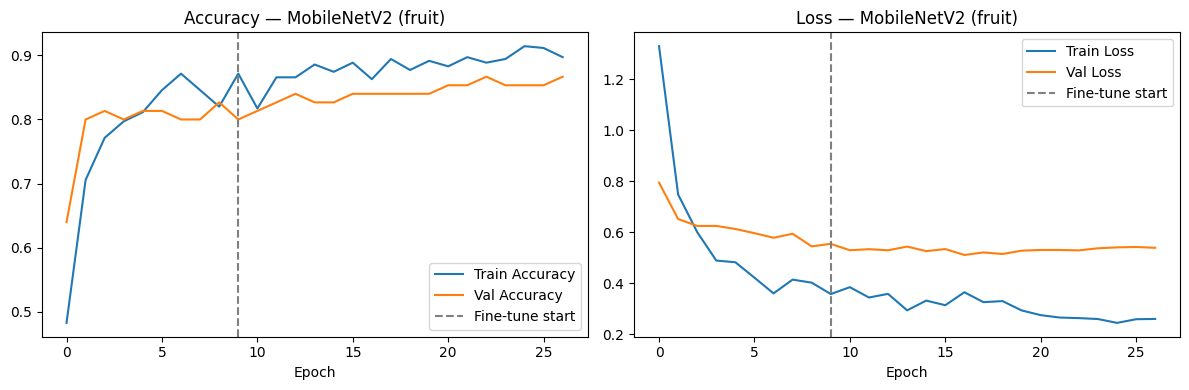

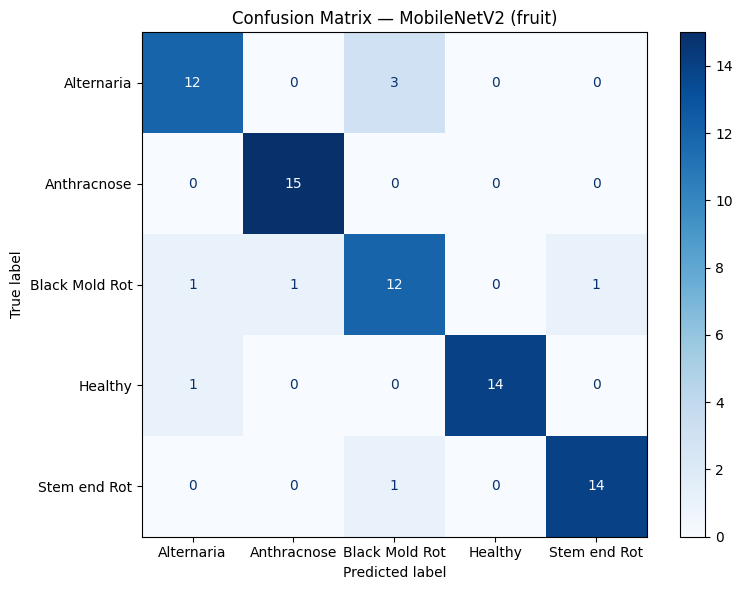

  Results saved to: /content/drive/MyDrive/MangoSense/models-mobilenetv2-fruit-2

  FINAL RESULTS — MobileNetV2
  leaves   Accuracy: 1.0000  Loss: 0.0024
  fruit    Accuracy: 0.8933  Loss: 0.2935


In [ ]:
"""
train-mobilenetv2-colab.py
--------------------------
Fine-tune MobileNetV2 (ImageNet weights) on mango disease datasets.
Used as a transfer-learning comparison baseline against MangoSenseNet models.

Two-phase fine-tuning:
  Phase 1 — Frozen base (10 epochs):  train only the classification head
  Phase 2 — Fine-tune  (40 epochs):   unfreeze top 30 layers, very low LR

Run on Colab:
  !python /content/drive/MyDrive/MangoSense/Scripts/train-mobilenetv2-colab.py
"""

import tensorflow as tf
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# COLAB SETUP — update BASE_DIR if your folder name differs
# ============================================================
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/MangoSense"
else:
    BASE_DIR = ""

def path_under_base(*parts):
    return os.path.join(BASE_DIR, *parts) if BASE_DIR else os.path.join(*parts)

# ============================================================
# CONFIG
# ============================================================
DATASETS = {
    "leaves": {
        "data_dir":        path_under_base("datasets", "preprocessed-leaves"),
        "save_dir":        path_under_base("models-mobilenetv2-leaves-2"),
        "img_size":        (224, 224),
        "batch_size":      32,
        "epochs_frozen":   10,
        "epochs_finetune": 40,
        "lr_frozen":       1e-3,
        "lr_finetune":     1e-5,
        "unfreeze_layers": 30,   # number of top MobileNetV2 layers to unfreeze
    },
    "fruit": {
        "data_dir":        path_under_base("datasets", "preprocessed-fruit"),
        "save_dir":        path_under_base("models-mobilenetv2-fruit-2"),
        "img_size":        (224, 224),
        "batch_size":      32,
        "epochs_frozen":   10,
        "epochs_finetune": 40,
        "lr_frozen":       1e-3,
        "lr_finetune":     1e-5,
        "unfreeze_layers": 30,
    },
}


# ============================================================
# Model builder
# ============================================================
def build_mobilenetv2(img_size, num_classes):
    """
    MobileNetV2 with ImageNet weights + custom classification head.
    Returns (model, base_model) so the base can be unfrozen later.
    """
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False  # Phase 1: all base layers frozen

    inputs = tf.keras.Input(shape=(*img_size, 3), name="image")

    # Same augmentation as custom models for fair comparison
    image_features = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ], name="augmentation")(inputs)

    # MobileNetV2 expects pixel values in [-1, 1]
    image_features = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name="preprocess")(image_features)

    # training=False keeps BatchNorm in inference mode (safe for frozen base)
    image_features = base_model(image_features, training=False)
    image_features = tf.keras.layers.GlobalAveragePooling2D(name="gap")(image_features)
    image_features = tf.keras.layers.Dense(256, activation="relu")(image_features)
    image_features = tf.keras.layers.Dropout(0.5)(image_features)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(image_features)

    model = tf.keras.Model(inputs, outputs, name="MobileNetV2_MangoSense")
    return model, base_model


def unfreeze_top_layers(base_model, num_layers):
    """Unfreeze the top `num_layers` of the base; keep all BatchNorm frozen."""
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers]:
        layer.trainable = False
    # Keep BatchNorm layers frozen to preserve ImageNet statistics
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False


# ============================================================
# Train each dataset
# ============================================================
all_results = {}

for dataset_name, dataset_config in DATASETS.items():
    data_dir        = dataset_config["data_dir"]
    save_dir        = dataset_config["save_dir"]
    img_size        = dataset_config["img_size"]
    batch_size      = dataset_config["batch_size"]
    epochs_frozen   = dataset_config["epochs_frozen"]
    epochs_finetune = dataset_config["epochs_finetune"]
    lr_frozen       = dataset_config["lr_frozen"]
    lr_finetune     = dataset_config["lr_finetune"]
    unfreeze_layers = dataset_config["unfreeze_layers"]

    print(f"\n{'='*55}")
    print(f"  Training MobileNetV2 — {dataset_name.upper()}")
    print(f"{'='*55}")
    print(f"  Phase 1: {epochs_frozen} epochs frozen  (LR={lr_frozen})")
    print(f"  Phase 2: {epochs_finetune} epochs fine-tune (LR={lr_finetune}, top {unfreeze_layers} layers)")
    print(f"  Image dir: {data_dir}")

    if not os.path.isdir(data_dir):
        print(f"  ERROR: Image directory not found: {data_dir}")
        continue

    AUTOTUNE = tf.data.AUTOTUNE

    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "train"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=True, seed=42,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "val"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=False,
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(data_dir, "test"),
        image_size=img_size, batch_size=batch_size,
        label_mode="categorical", shuffle=False,
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"  Classes ({num_classes}): {class_names}")

    train_ds = train_ds.cache().shuffle(1000, seed=42).prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(AUTOTUNE)

    model, base_model = build_mobilenetv2(img_size, num_classes)
    model.summary()
    print(f"  Total parameters (phase 1): {model.count_params():,}")

    os.makedirs(save_dir, exist_ok=True)

    # ── Phase 1: frozen base, train head only ──────────────────────────────────
    print(f"\n  ── Phase 1: Training classification head (base frozen) ──")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_frozen),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    ckpt_path = os.path.join(save_dir, "best_model.keras")
    callbacks_p1 = [
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
    ]

    history_phase1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs_frozen,
        callbacks=callbacks_p1,
        verbose=1,
    )

    # ── Phase 2: unfreeze top layers, fine-tune ────────────────────────────────
    print(f"\n  ── Phase 2: Fine-tuning top {unfreeze_layers} layers ──")
    unfreeze_top_layers(base_model, unfreeze_layers)
    trainable_count = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"  Trainable parameters (phase 2): {trainable_count:,}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_finetune),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks_p2 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
    ]

    history_phase2 = model.fit(
        train_ds, validation_data=val_ds,
        initial_epoch=epochs_frozen,
        epochs=epochs_frozen + epochs_finetune,
        callbacks=callbacks_p2,
        verbose=1,
    )

    # ── Evaluation ─────────────────────────────────────────────────────────────
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\n  Test Accuracy : {test_acc:.4f}")
    print(f"  Test Loss     : {test_loss:.4f}")

    y_pred_probs  = model.predict(test_ds, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_true        = np.argmax(
        np.concatenate([y.numpy() for _, y in test_ds]), axis=1
    )

    report = classification_report(y_true, y_pred_labels, target_names=class_names, digits=4)
    print("\nClassification Report:")
    print(report)

    # ── Save artifacts ──────────────────────────────────────────────────────────
    model.save(os.path.join(save_dir, "mobilenetv2.keras"))

    # Merge phase 1 and phase 2 histories for one continuous training curve
    full_history = {
        metric_name: history_phase1.history.get(metric_name, []) + history_phase2.history.get(metric_name, [])
        for metric_name in set(list(history_phase1.history) + list(history_phase2.history))
    }
    with open(os.path.join(save_dir, "history.json"), "w") as output_file:
        json.dump(full_history, output_file)

    with open(os.path.join(save_dir, "classification_report.txt"), "w") as output_file:
        output_file.write(f"Dataset: {dataset_name}\n")
        output_file.write(f"Test Accuracy: {test_acc:.4f}\n")
        output_file.write(f"Test Loss:     {test_loss:.4f}\n\n")
        output_file.write(report)

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(full_history["accuracy"],     label="Train Accuracy")
    axes[0].plot(full_history["val_accuracy"], label="Val Accuracy")
    axes[0].axvline(x=epochs_frozen - 1, color="gray", linestyle="--", label="Fine-tune start")
    axes[0].set_title(f"Accuracy — MobileNetV2 ({dataset_name})")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(full_history["loss"],     label="Train Loss")
    axes[1].plot(full_history["val_loss"], label="Val Loss")
    axes[1].axvline(x=epochs_frozen - 1, color="gray", linestyle="--", label="Fine-tune start")
    axes[1].set_title(f"Loss — MobileNetV2 ({dataset_name})")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
    plt.show()

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap="Blues", ax=ax)
    plt.title(f"Confusion Matrix — MobileNetV2 ({dataset_name})")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
    plt.show()

    all_results[dataset_name] = {"test_accuracy": round(test_acc, 4), "test_loss": round(test_loss, 4)}
    print(f"  Results saved to: {save_dir}")

# ============================================================
# Final summary
# ============================================================
print(f"\n{'='*45}")
print("  FINAL RESULTS — MobileNetV2")
print(f"{'='*45}")
for dataset_name, result_summary in all_results.items():
    print(f"  {dataset_name:<8} Accuracy: {result_summary['test_accuracy']:.4f}  Loss: {result_summary['test_loss']:.4f}")


In [ ]:
"""
test-hybrid-gui-colab.py
------------------------
Interactive GUI for MangoSenseNet-Hybrid in Google Colab.
Uses ipywidgets — run this file with:

    %run /content/drive/MyDrive/MangoSense/Scripts/test-hybrid-gui-colab.py

Then interact with the widgets that appear below the cell.
"""

import tensorflow as tf
import numpy as np
import json, os, io, joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage

# ============================================================
# COLAB SETUP — update BASE_DIR if your folder name differs
# ============================================================
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/MangoSense"
else:
    BASE_DIR = ""

def path_under_base(*parts):
    return os.path.join(BASE_DIR, *parts) if BASE_DIR else os.path.join(*parts)

# ============================================================
# MODEL CONFIG
# ============================================================
MODEL_CONFIGS = {
    "Leaf  — 5 classes (Anthracnose, Die Back, Healthy, Powdery Mildew, Sooty Mold)": {
        "model_path":  path_under_base("models-custom-hybrid-leaves-obj", "best_model.keras"),
        "proto_path":  path_under_base("models-custom-hybrid-leaves-obj", "class_symptom_prototypes.json"),
        "feat_path":   path_under_base("models-custom-hybrid-leaves-obj", "feature_columns.json"),
        "img_size":    (240, 240),
    },
    "Fruit — 5 classes (Alternaria, Anthracnose, Black Mold Rot, Healthy, Stem end Rot)": {
        "model_path":  path_under_base("models-custom-hybrid-fruit-obj", "best_model.keras"),
        "proto_path":  path_under_base("models-custom-hybrid-fruit-obj", "class_symptom_prototypes.json"),
        "feat_path":   path_under_base("models-custom-hybrid-fruit-obj", "feature_columns.json"),
        "img_size":    (240, 240),
    },
}

# ============================================================
# Load models at startup
# ============================================================
print("Loading MangoSenseNet-Hybrid models...")
loaded = {}
for label, dataset_config in MODEL_CONFIGS.items():
    try:
        model = tf.keras.models.load_model(dataset_config["model_path"])
        with open(dataset_config["proto_path"]) as input_file:
            proto_dict = json.load(input_file)
        with open(dataset_config["feat_path"]) as input_file:
            feature_cols = json.load(input_file)
        loaded[label] = {
            "model":        model,
            "proto_dict":   proto_dict,
            "feature_cols": feature_cols,
            "img_size":     dataset_config["img_size"],
            "class_names":  sorted(proto_dict.keys()),
        }
        print(f"  ✓ Loaded: {label.split('—')[0].strip()}")
    except Exception as e:
        print(f"  ✗ Failed ({label.split('—')[0].strip()}): {e}")

if not loaded:
    raise RuntimeError("No models loaded. Check your BASE_DIR and model paths.")

# ============================================================
# Prediction helper
# ============================================================
def predict(img_bytes, model_label):
    dataset_config = loaded[model_label]
    model       = dataset_config["model"]
    proto_dict  = dataset_config["proto_dict"]
    feat_cols   = dataset_config["feature_cols"]
    class_names = dataset_config["class_names"]
    img_size    = dataset_config["img_size"]

    # Decode image from bytes
    pil_img = PILImage.open(io.BytesIO(img_bytes)).convert("RGB")
    pil_img = pil_img.resize(img_size, PILImage.LANCZOS)
    img_arr = np.array(pil_img, dtype=np.float32)
    img_batch = np.expand_dims(img_arr, 0)          # (1, H, W, 3)

    # Pass 1 — zero symptoms (image branch drives initial guess)
    zero_sym  = np.zeros((1, len(feat_cols)), dtype=np.float32)
    probs_p1  = model({"image": img_batch, "symptoms": zero_sym}, training=False).numpy()[0]
    top_class = class_names[int(np.argmax(probs_p1))]

    # Pass 2 — top-class prototype (refine with symptom knowledge)
    proto_vec = np.array([proto_dict[top_class]], dtype=np.float32)
    probs     = model({"image": img_batch, "symptoms": proto_vec}, training=False).numpy()[0]
    pred_idx  = int(np.argmax(probs))

    return pil_img, probs, pred_idx, class_names


def render_result(pil_img, probs, pred_idx, class_names, model_label):
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx]) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left — uploaded image
    axes[0].imshow(pil_img)
    axes[0].set_title("Uploaded Image", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    # Right — probability bar chart
    colors = ["#4CAF50" if i == pred_idx else "#90CAF9" for i in range(len(class_names))]
    bars = axes[1].barh(class_names, probs * 100, color=colors, edgecolor="white", height=0.6)
    axes[1].set_xlim(0, 118)
    axes[1].set_xlabel("Confidence (%)", fontsize=11)
    axes[1].set_title("Prediction Probabilities", fontsize=13, fontweight="bold")
    axes[1].invert_yaxis()

    for bar, prob in zip(bars, probs):
        axes[1].text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{prob*100:.1f}%", va="center", fontsize=10
        )

    legend = [mpatches.Patch(color="#4CAF50", label=f"Predicted: {pred_label}  ({confidence:.1f}%)")]
    axes[1].legend(handles=legend, loc="lower right", fontsize=11)

    dtype = "Leaf" if "Leaf" in model_label else "Fruit"
    plt.suptitle(
        f"MangoSenseNet-Hybrid  ·  {dtype}  →  {pred_label}",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    # Text summary
    print(f"\n{'─'*45}")
    print(f"  Prediction : {pred_label}")
    print(f"  Confidence : {confidence:.2f}%")
    print(f"{'─'*45}")
    for cls, prob in zip(class_names, probs):
        bar  = "█" * int(prob * 35)
        mark = " ◀ predicted" if cls == pred_label else ""
        print(f"  {cls:<22} {prob*100:5.1f}%  {bar}{mark}")


# ============================================================
# Widget UI
# ============================================================
title = widgets.HTML(
    value="""
    <div style='background:#1B5E20;padding:14px 20px;border-radius:8px;margin-bottom:8px'>
      <h2 style='color:white;margin:0;font-family:sans-serif'>
        🥭 MangoSenseNet-Hybrid — Disease Detector
      </h2>
      <p style='color:#C8E6C9;margin:4px 0 0;font-size:13px'>
        Upload a mango leaf or fruit image and click Analyze
      </p>
    </div>
    """
)

model_dropdown = widgets.Dropdown(
    options=list(MODEL_CONFIGS.keys()),
    description="",
    layout=widgets.Layout(width="620px"),
    style={"description_width": "0px"},
)

upload_btn = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="info",
    layout=widgets.Layout(width="180px"),
)

analyze_btn = widgets.Button(
    description="Analyze",
    button_style="success",
    icon="search",
    layout=widgets.Layout(width="130px", height="36px"),
)

clear_btn = widgets.Button(
    description="Clear",
    button_style="warning",
    icon="times",
    layout=widgets.Layout(width="100px", height="36px"),
)

status_label = widgets.HTML(
    value="<span style='color:gray;font-size:13px'>Upload an image to begin.</span>"
)

output_area = widgets.Output()

# -------- callbacks --------
def on_analyze(b):
    with output_area:
        clear_output(wait=True)

        if not upload_btn.value:
            status_label.value = "<span style='color:red'>⚠ Please upload an image first.</span>"
            return

        model_label = model_dropdown.value
        if model_label not in loaded:
            status_label.value = f"<span style='color:red'>⚠ Model not loaded: {model_label}</span>"
            return

        # Get uploaded file bytes
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file["content"]
        fname     = list(upload_btn.value.keys())[0]

        status_label.value = f"<span style='color:#1565C0'>⏳ Analyzing <b>{fname}</b>…</span>"
        analyze_btn.disabled = True

        try:
            pil_img, probs, pred_idx, class_names = predict(img_bytes, model_label)
            render_result(pil_img, probs, pred_idx, class_names, model_label)
            pred_label = class_names[pred_idx]
            conf = float(probs[pred_idx]) * 100
            status_label.value = (
                f"<span style='color:#1B5E20'>✓ Done — "
                f"<b>{pred_label}</b> ({conf:.1f}%)</span>"
            )
        except Exception as e:
            status_label.value = f"<span style='color:red'>Error: {e}</span>"
            print(f"Error during prediction: {e}")
        finally:
            analyze_btn.disabled = False


def on_clear(b):
    with output_area:
        clear_output()
    status_label.value = "<span style='color:gray;font-size:13px'>Cleared. Upload a new image.</span>"


analyze_btn.on_click(on_analyze)
clear_btn.on_click(on_clear)

# -------- layout --------
controls = widgets.HBox(
    [upload_btn, analyze_btn, clear_btn],
    layout=widgets.Layout(gap="10px", align_items="center", margin="8px 0"),
)

ui = widgets.VBox(
    [title, model_dropdown, controls, status_label, output_area],
    layout=widgets.Layout(padding="10px"),
)

display(ui)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading MangoSenseNet-Hybrid models...
  ✓ Loaded: Leaf
  ✓ Loaded: Fruit


In [ ]:
"""
test-mobilenetv2-gui-colab.py
------------------------------
Interactive GUI for the fine-tuned MobileNetV2 models in Google Colab.
Uses ipywidgets — run with:

    %run /content/drive/MyDrive/MangoSense/Scripts/test-mobilenetv2-gui-colab.py
"""

import tensorflow as tf
import numpy as np
import json, os, io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage

# ============================================================
# COLAB SETUP
# ============================================================
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/MangoSense"
else:
    BASE_DIR = ""

def path_under_base(*parts):
    return os.path.join(BASE_DIR, *parts) if BASE_DIR else os.path.join(*parts)

# ============================================================
# MODEL CONFIG
# Class names must match alphabetical order used by
# image_dataset_from_directory during training.
# ============================================================
MODEL_CONFIGS = {
    "Leaf  — 5 classes (Anthracnose, Die Back, Healthy, Powdery Mildew, Sooty Mold)": {
        "model_path":  path_under_base("models-mobilenetv2-leaves-2", "best_model.keras"),
        "class_names": ["Anthracnose", "Die Back", "Healthy", "Powdery Mildew", "Sooty Mold"],
        "img_size":    (224, 224),
    },
    "Fruit — 5 classes (Alternaria, Anthracnose, Black Mold Rot, Healthy, Stem end Rot)": {
        "model_path":  path_under_base("models-mobilenetv2-fruit-2", "best_model.keras"),
        "class_names": ["Alternaria", "Anthracnose", "Black Mold Rot", "Healthy", "Stem end Rot"],
        "img_size":    (224, 224),
    },
}

# ============================================================
# Load models at startup
# ============================================================
print("Loading MobileNetV2 models...")
loaded = {}
for label, dataset_config in MODEL_CONFIGS.items():
    try:
        model = tf.keras.models.load_model(dataset_config["model_path"])
        loaded[label] = {
            "model":       model,
            "class_names": dataset_config["class_names"],
            "img_size":    dataset_config["img_size"],
        }
        print(f"  ✓ Loaded: {label.split('—')[0].strip()}")
    except Exception as e:
        print(f"  ✗ Failed ({label.split('—')[0].strip()}): {e}")

if not loaded:
    raise RuntimeError("No models loaded. Check your BASE_DIR and model paths.")

# ============================================================
# Prediction helper
# ============================================================
def predict(img_bytes, model_label):
    dataset_config = loaded[model_label]
    model       = dataset_config["model"]
    class_names = dataset_config["class_names"]
    img_size    = dataset_config["img_size"]

    pil_img   = PILImage.open(io.BytesIO(img_bytes)).convert("RGB")
    pil_img   = pil_img.resize(img_size, PILImage.LANCZOS)
    img_arr   = np.array(pil_img, dtype=np.float32)
    img_batch = np.expand_dims(img_arr, 0)   # (1, H, W, 3)

    probs    = model(img_batch, training=False).numpy()[0]
    pred_idx = int(np.argmax(probs))

    return pil_img, probs, pred_idx, class_names


def render_result(pil_img, probs, pred_idx, class_names, model_label):
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx]) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].imshow(pil_img)
    axes[0].set_title("Uploaded Image", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    colors = ["#4CAF50" if i == pred_idx else "#90CAF9" for i in range(len(class_names))]
    bars = axes[1].barh(class_names, probs * 100, color=colors, edgecolor="white", height=0.6)
    axes[1].set_xlim(0, 118)
    axes[1].set_xlabel("Confidence (%)", fontsize=11)
    axes[1].set_title("Prediction Probabilities", fontsize=13, fontweight="bold")
    axes[1].invert_yaxis()

    for bar, prob in zip(bars, probs):
        axes[1].text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{prob*100:.1f}%", va="center", fontsize=10,
        )

    legend = [mpatches.Patch(color="#4CAF50", label=f"Predicted: {pred_label}  ({confidence:.1f}%)")]
    axes[1].legend(handles=legend, loc="lower right", fontsize=11)

    dtype = "Leaf" if "Leaf" in model_label else "Fruit"
    plt.suptitle(
        f"MobileNetV2  ·  {dtype}  →  {pred_label}",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{'─'*45}")
    print(f"  Prediction : {pred_label}")
    print(f"  Confidence : {confidence:.2f}%")
    print(f"{'─'*45}")
    for cls, prob in zip(class_names, probs):
        bar  = "█" * int(prob * 35)
        mark = " ◀ predicted" if cls == pred_label else ""
        print(f"  {cls:<22} {prob*100:5.1f}%  {bar}{mark}")


# ============================================================
# Widget UI
# ============================================================
title = widgets.HTML(
    value="""
    <div style='background:#1A237E;padding:14px 20px;border-radius:8px;margin-bottom:8px'>
      <h2 style='color:white;margin:0;font-family:sans-serif'>
        🥭 MobileNetV2 — Mango Disease Detector
      </h2>
      <p style='color:#C5CAE9;margin:4px 0 0;font-size:13px'>
        Upload a mango leaf or fruit image and click Analyze
      </p>
    </div>
    """
)

model_dropdown = widgets.Dropdown(
    options=list(MODEL_CONFIGS.keys()),
    description="",
    layout=widgets.Layout(width="620px"),
    style={"description_width": "0px"},
)

upload_btn = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="info",
    layout=widgets.Layout(width="180px"),
)

analyze_btn = widgets.Button(
    description="Analyze",
    button_style="success",
    icon="search",
    layout=widgets.Layout(width="130px", height="36px"),
)

clear_btn = widgets.Button(
    description="Clear",
    button_style="warning",
    icon="times",
    layout=widgets.Layout(width="100px", height="36px"),
)

status_label = widgets.HTML(
    value="<span style='color:gray;font-size:13px'>Upload an image to begin.</span>"
)

output_area = widgets.Output()


def on_analyze(b):
    with output_area:
        clear_output(wait=True)

        if not upload_btn.value:
            status_label.value = "<span style='color:red'>⚠ Please upload an image first.</span>"
            return

        model_label = model_dropdown.value
        if model_label not in loaded:
            status_label.value = f"<span style='color:red'>⚠ Model not loaded: {model_label}</span>"
            return

        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file["content"]
        fname     = list(upload_btn.value.keys())[0]

        status_label.value = f"<span style='color:#1565C0'>⏳ Analyzing <b>{fname}</b>…</span>"
        analyze_btn.disabled = True

        try:
            pil_img, probs, pred_idx, class_names = predict(img_bytes, model_label)
            render_result(pil_img, probs, pred_idx, class_names, model_label)
            pred_label = class_names[pred_idx]
            conf = float(probs[pred_idx]) * 100
            status_label.value = (
                f"<span style='color:#1B5E20'>✓ Done — "
                f"<b>{pred_label}</b> ({conf:.1f}%)</span>"
            )
        except Exception as e:
            status_label.value = f"<span style='color:red'>Error: {e}</span>"
            print(f"Error during prediction: {e}")
        finally:
            analyze_btn.disabled = False


def on_clear(b):
    with output_area:
        clear_output()
    status_label.value = "<span style='color:gray;font-size:13px'>Cleared. Upload a new image.</span>"


analyze_btn.on_click(on_analyze)
clear_btn.on_click(on_clear)

controls = widgets.HBox(
    [upload_btn, analyze_btn, clear_btn],
    layout=widgets.Layout(gap="10px", align_items="center", margin="8px 0"),
)

ui = widgets.VBox(
    [title, model_dropdown, controls, status_label, output_area],
    layout=widgets.Layout(padding="10px"),
)

display(ui)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading MobileNetV2 models...
  ✓ Loaded: Leaf
  ✓ Loaded: Fruit
